In [1]:

from google.colab import files
import os
from pathlib import Path

def extract_artist_from_filename(name: str) -> str:
    stem = Path(name).stem
    parts = stem.split('_')
    if parts and parts[-1].isdigit():
        artist_parts = parts[:-1]
    else:
        artist_parts = parts
    return ' '.join(artist_parts)

print("Faça upload do arquivo 'resized.zip'")
uploaded = files.upload()  # selecione resized.zip

if "resized.zip" in uploaded:
    print("Upload concluído. Descompactando...")
    !unzip -q resized.zip -d .

    if os.path.isdir("resized"):
        print("Pasta 'resized/' pronta.")

        # Listar artistas disponíveis
        print("\nArtistas encontrados (exibindo até 15):")
        all_files = list(Path("resized").glob("*.*"))
        artists = {}
        for f in all_files:
            try:
                artist = extract_artist_from_filename(f.name)
                artists[artist] = artists.get(artist, 0) + 1
            except:
                continue

        for i, (artist, count) in enumerate(sorted(artists.items())):
            if i >= 18:
                print("  ... (mais artistas disponíveis)")
                break
            print(f"  • {artist} ({count} obra{'s' if count != 1 else ''})")


        if artists:
            sample = next(iter(artists))
            print(f"\nPara usar um artista, copie o nome exato: '{sample}'")
        else:
            print("Nenhum artista detectado — verifique os nomes dos arquivos (ex: 'Artista_Nome_1.jpg').")

    else:
        raise RuntimeError("Pasta 'resized/' não encontrada após descompactação.")
else:
    raise FileNotFoundError("Arquivo 'resized.zip' não foi carregado.")

Faça upload do arquivo 'resized.zip'


Saving resized.zip to resized.zip
Upload concluído. Descompactando...
Pasta 'resized/' pronta.

Artistas encontrados (exibindo até 15):
  • Andy Warhol (181 obras)
  • Claude Monet (73 obras)
  • Edvard Munch (67 obras)
  • Francisco Goya (291 obras)
  • Frida Kahlo (120 obras)
  • Gustave Courbet (59 obras)
  • Henri de Toulouse-Lautrec (81 obras)
  • Leonardo da Vinci (143 obras)
  • Michelangelo (49 obras)
  • Pablo Picasso (439 obras)
  • Paul Cezanne (47 obras)
  • Peter Paul Rubens (141 obras)
  • Pierre-Auguste Renoir (336 obras)
  • Raphael (109 obras)
  • Rembrandt (262 obras)
  • Salvador Dali (139 obras)
  • Sandro Botticelli (164 obras)
  • Vincent van Gogh (877 obras)

Para usar um artista, copie o nome exato: 'Francisco Goya'


In [17]:
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm import tqdm
import re

def extract_artist_from_filename(name: str) -> str:
    stem = Path(name).stem
    artist = '_'.join(stem.split('_')[:-1])
    return artist.replace('_', ' ')

#      MUDA O PINTOR AQUI !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
artist = "Vincent van Gogh"

all_files = list(Path("resized").glob("*.*"))
target_files = [
    f for f in all_files
    if extract_artist_from_filename(f.name) == artist and f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
]

print(f"Encontrados {len(target_files)} arquivos para '{artist}'")


images = []
for f in tqdm(target_files[:60]):  # limite para 60
    try:
        img = Image.open(f).convert("RGB")
        img = img.resize((128, 128), Image.LANCZOS)
        arr = np.array(img, dtype=np.float32) / 255.0
        if arr.shape == (128, 128, 3):
            images.append(arr)
    except Exception as e:
        continue

if not images:
    raise RuntimeError(f"Nenhuma imagem válida carregada para '{artist}'.")

X = np.array(images)
n, h, w, c = X.shape
X_flat = X.reshape(n, -1)
print(f"\nMatriz final: {X.shape} → {X_flat.shape}")

print(f"\n Pronto para {n} pinturas de '{artist}'.")
CURRENT_ARTIST = artist

Encontrados 877 arquivos para 'Vincent van Gogh'


100%|██████████| 60/60 [00:01<00:00, 33.59it/s]


Matriz final: (60, 128, 128, 3) → (60, 49152)

 Pronto para 60 pinturas de 'Vincent van Gogh'.


In [18]:
from sklearn.decomposition import PCA

print("▶ Executando PCA (n_components=2)...")
pca = PCA(n_components=2, random_state=42)
X_centered = X_flat - X_flat.mean(axis=0)
scores = pca.fit_transform(X_centered)

print(f"Variância explicada: PC1 = {pca.explained_variance_ratio_[0]:.2%}, PC2 = {pca.explained_variance_ratio_[1]:.2%}")

# Média e PCs como imagens
mean_img = X.mean(axis=0)  # (128,128,3)
pc1_img = pca.components_[0].reshape(128, 128, 3)
pc2_img = pca.components_[1].reshape(128, 128, 3)

def visualize_pc(pc, scale=2.0):
    deviation = scale * pc
    img = np.clip(mean_img + deviation, 0, 1)
    return img

▶ Executando PCA (n_components=2)...
Variância explicada: PC1 = 35.54%, PC2 = 8.87%


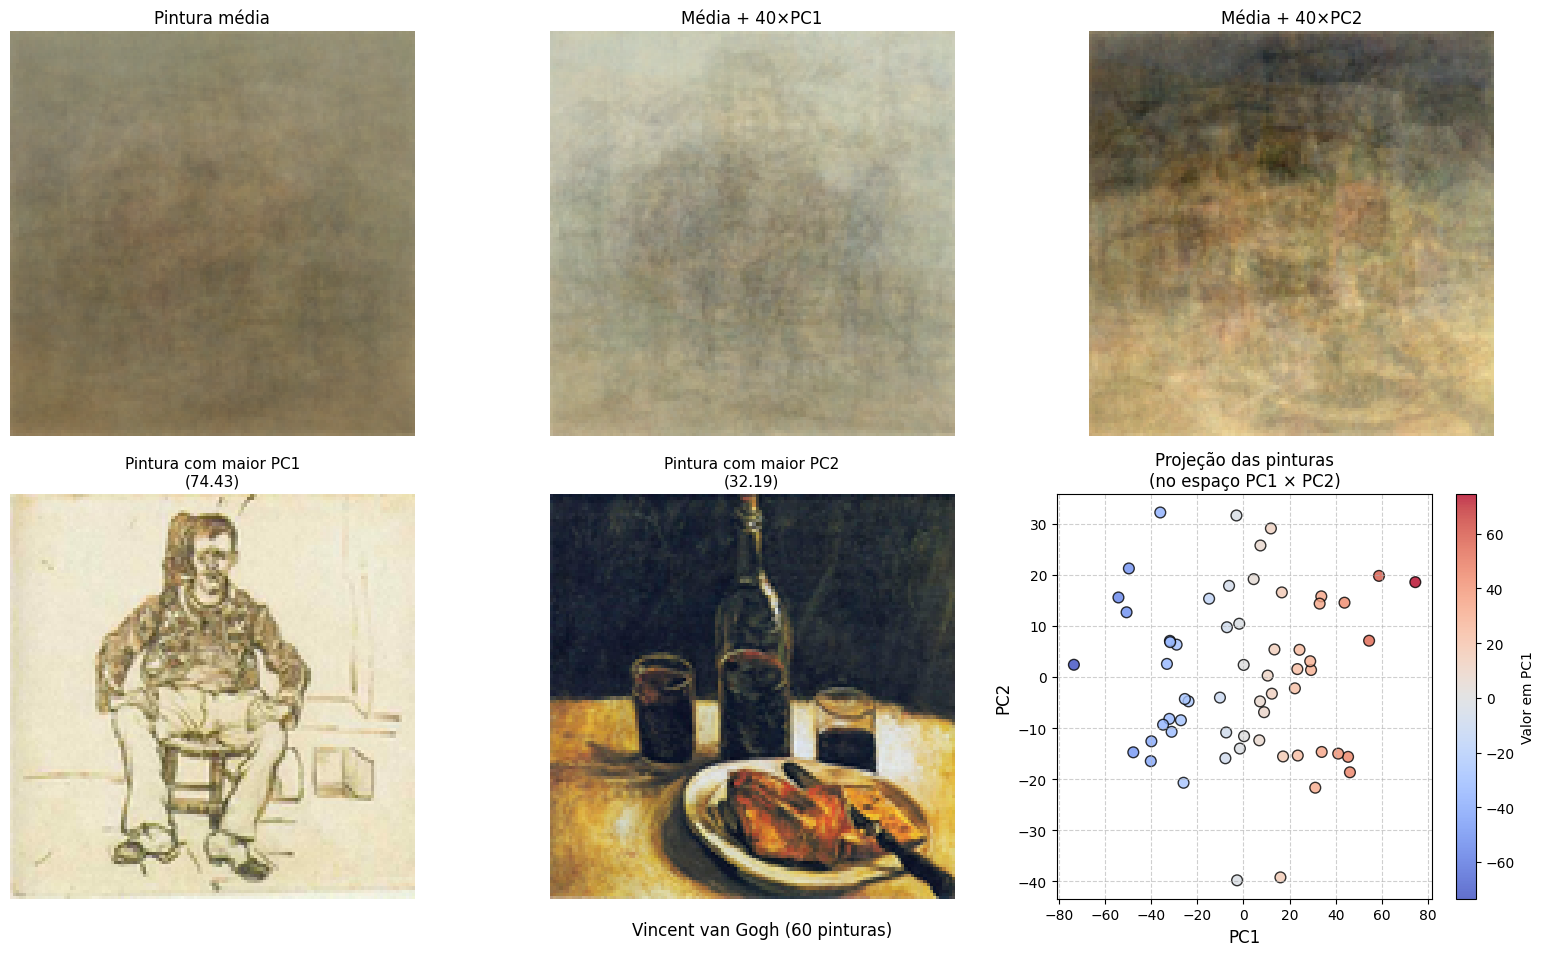

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 1. Pintura média
axes[0].imshow(mean_img)
axes[0].set_title("Pintura média", fontsize=12)
axes[0].axis("off")

# 2. PC1 (modo dominante)
axes[1].imshow(visualize_pc(pc1_img, scale=40.0))
axes[1].set_title("Média + 40×PC1", fontsize=12)
axes[1].axis("off")

# 3. PC2
axes[2].imshow(visualize_pc(pc2_img, scale=40.0))
axes[2].set_title("Média + 40×PC2", fontsize=12)
axes[2].axis("off")

# 4. Pintura mais próxima do PC1 (máximo em PC1)
idx_max_pc1 = scores[:, 0].argmax()
axes[3].imshow(X[idx_max_pc1])
axes[3].set_title(f"Pintura com maior PC1\n({scores[idx_max_pc1, 0]:.2f})", fontsize=11)
axes[3].axis("off")

# 5. Pintura mais próxima do PC2 (máximo em PC2)
idx_max_pc2 = scores[:, 1].argmax()
axes[4].imshow(X[idx_max_pc2])
axes[4].set_title(f"Pintura com maior PC2\n({scores[idx_max_pc2, 1]:.2f})", fontsize=11)
axes[4].axis("off")

# 6. Gráfico de dispersão: PC1 × PC2
sc = axes[5].scatter(scores[:, 0], scores[:, 1], c=scores[:, 0], cmap="coolwarm", alpha=0.8, edgecolor="k", s=60)
axes[5].set_xlabel("PC1", fontsize=12)
axes[5].set_ylabel("PC2", fontsize=12)
axes[5].set_title("Projeção das pinturas\n(no espaço PC1 × PC2)", fontsize=12)
axes[5].grid(True, linestyle="--", alpha=0.6)
plt.colorbar(sc, ax=axes[5], label="Valor em PC1")

plt.suptitle(f"{artist} ({n} pinturas)", fontsize=12, y=0.04)
plt.tight_layout()
plt.show()